# Simulation Experiment

> In this notebook we demonstrate the how to train the MixMIL model on data simulated in a multi instance linear regression setting (Normal likelihood)

In [3]:
import numpy as np
import scipy.stats as st
import torch


from mixmil import MixMIL
import pandas as pd
import matplotlib.pyplot as plt
import scipy.special as sp
from sklearn.linear_model import LinearRegression, LogisticRegression
import statsmodels.api as sm


## Training

In [4]:
N = 1_000
Q = 50
K = 1
P = 1   
F = np.ones((N, K))
I_lower = 100
I_upper = 500
iidx = np.concatenate([np.repeat(i, np.random.randint(I_lower, I_upper)) for i in range(N)])
indptr = np.concatenate([[0], np.cumsum(np.bincount(iidx))])
C = iidx.shape[0]
sizes = indptr[1:] - indptr[:-1]
X = np.random.randn(C, Q)
X = (X - X.mean(axis=0, keepdims=True)) / (np.sqrt(Q) * X.std(axis=0, keepdims=True))
Xs = [X[indptr[i]:indptr[i+1]] for i in range(N)]
gamma = np.random.randn(Q,2) * 1 # coefficients to predict weights
beta = np.random.randn(Q,2) * 0.5 # coefficients to predict outcome from bag embedding
alpha = 0.1 # intercept
u = X @ gamma

b = np.sqrt((beta**2).mean(0, keepdims=True))
w = np.concatenate([sp.softmax(u[s:e], axis=0) for s, e in zip(indptr[:-1], indptr[1:])])
t = X @ beta
u = np.concatenate([(w[s:e] * t[s:e]).sum(axis=0, keepdims=True) for s, e in zip(indptr[:-1], indptr[1:])])
u = b * (u - u.mean(0)) / u.std(0)
logits = F * alpha + u

probs = sp.softmax(logits, axis=1)
Y = probs.argmax(1, keepdims=True)


dtype = torch.float32
Xs, F, Y = [torch.tensor(x, dtype=dtype) for x in Xs], torch.tensor(F, dtype=dtype), torch.tensor(Y, dtype=dtype)

/Users/jan.engelmann/mambaforge/envs/testmm/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


alpha torch.Size([1, 1])
log_sigma_u torch.Size([1, 1])
log_sigma_z torch.Size([1, 1])
posterior.mu torch.Size([1, 100])
posterior.cov_factor torch.Size([1, 100, 100])
posterior.cov_logdiag torch.Size([1, 100])
(1000,)


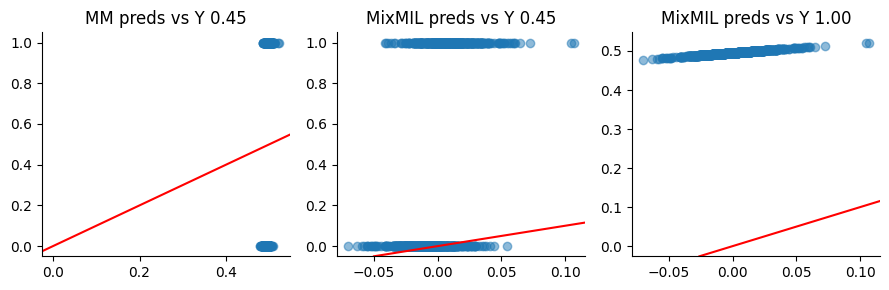

In [5]:
X_m = np.concatenate([x.numpy().mean(axis=0, keepdims=True) for x in Xs])
F_X_m = np.concatenate([F, X_m], axis=1)
mm = LogisticRegression(fit_intercept=False).fit(F_X_m, Y.numpy())

mm_preds = mm.predict_proba(F_X_m)[:, 1].ravel()
Y_flat = Y.numpy().ravel()

model = MixMIL(Q, K, P, likelihood="binomial", n_trials=1)
sd = model.state_dict()
for name, param in sd.items():
    print(name, param.shape)
sd["alpha"] = torch.tensor(mm.coef_.ravel()[0]).reshape(1, 1)
beta = mm.coef_.ravel()[1:]
u = X_m.dot(beta)
beta = u.std() * beta / np.sqrt((beta**2).mean())
beta = torch.tensor(beta).reshape(1, -1)
sd["posterior.mu"] = torch.cat([sd["posterior.mu"][:, :50], beta], dim=1)
model.load_state_dict(sd)

mix_preds = model.predict(Xs).ravel().numpy()
print(mix_preds.shape)
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
axs[0].scatter(mm_preds, Y_flat, alpha=0.5)
rho = st.pearsonr(mm_preds, Y_flat)[0]
axs[0].set_title(f"MM preds vs Y {rho:.2f}")
axs[1].scatter(mix_preds, Y_flat, alpha=0.5)
rho = st.pearsonr(mix_preds, Y_flat)[0]
axs[1].set_title(f"MixMIL preds vs Y {rho:.2f}")



axs[2].scatter(mix_preds, mm_preds, alpha=0.5)
rho = st.pearsonr(mix_preds, mm_preds)[0]
axs[2].set_title(f"MixMIL preds vs Y {rho:.2f}")

for ax in axs:
    ax.spines[["top", "right"]].set_visible(False)
    ax.axline((0,0), slope=1, color="red")
fig.tight_layout()

In [180]:
hist = model.train(Xs, F, Y, n_epochs=1_000)

Epoch:   0%|          | 0/1000 [00:00<?, ?it/s]

In [181]:
hdf = pd.DataFrame(hist)
hdf

,loss,ll,kld,epoch,step
0,1.448029,-1.217344,0.230686,1,0
1,1.551032,-1.327381,0.223651,1,1
2,1.393786,-1.177651,0.216135,1,2
3,1.416995,-1.208804,0.208191,1,3
4,1.409789,-1.209618,0.200171,1,4
...,...,...,...,...,...
15995,-0.155345,0.438424,0.283079,1000,11
15996,0.228780,0.054207,0.282986,1000,12
15997,-0.064462,0.347398,0.282936,1000,13
15998,0.309495,-0.026670,0.282825,1000,14


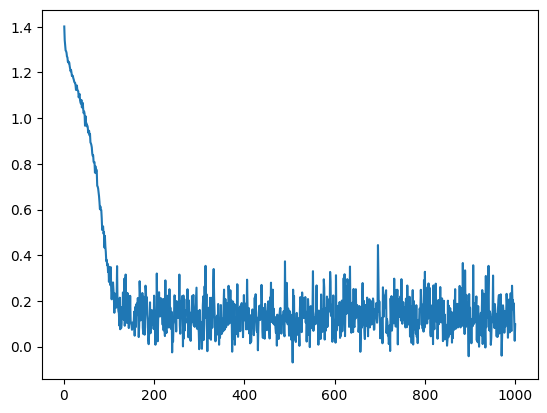

In [185]:
plt.plot(hdf.groupby("epoch").loss.mean())

In [186]:
pred = model.predict(Xs)
pred = pred.detach().cpu().numpy()
st.pearsonr(Y.ravel(), pred.ravel()), st.spearmanr(Y.ravel(), pred.ravel())

(PearsonRResult(statistic=0.9956754560009085, pvalue=0.0),
 SignificanceResult(statistic=0.9946199146199148, pvalue=0.0))

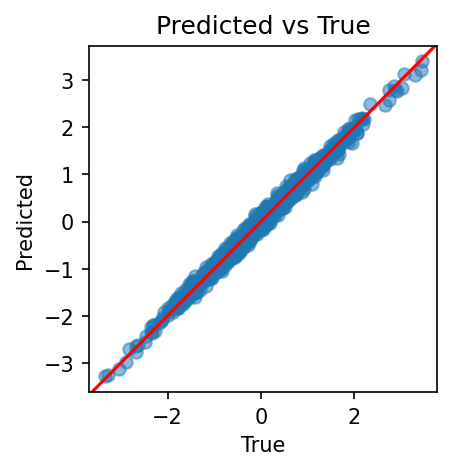

In [187]:
fig, ax = plt.subplots(figsize=(3,3), dpi=150)
ax.scatter(Y.ravel(), pred.ravel(), alpha=0.5)
ax.set_xlabel("True")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs True")
ax.axline((0,0), slope=1, color="red")
